## Circumpolar maps

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [14]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl

In [15]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [16]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func

In [17]:
# import imp
# imp.reload(func)

In [18]:
savepath = os.path.join(workingdir, 'figures')

### Import data

In [24]:
file = 'data/circumpolar_satGEM_on_dens_2010_2020.nc'
### circumpolar SatGEM on density, 2010-2020 mean fields
circumpolar_satgem = xr.open_dataset(file)

In [26]:
### mean dynamic topography (Aviso) 
circumpolar_mdt = xr.open_dataset('data/circumpolar_mdt.nc')

### SatGEM Temperature

Text(0.5, 1.0, '$\\rho$ = 27.0-27.5 kg m$^{-3}$')

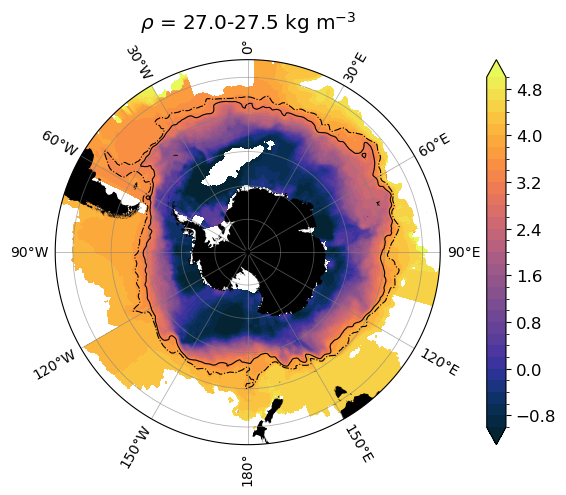

In [27]:
mean_t = circumpolar_satgem.temp.sel(density = slice(27.0, 27.5)).mean(dim = 'density')

fig, ax = func.plot_circmupolar(mean_t, cmap = cmocean.cm.thermal, levels  = np.arange(-1, 5.2, 0.2))

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 0.8, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 0.8, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title(r'$\rho$ = 27.0-27.5 kg m$^{-3}$')

### SatGEM Temperature gradients

In [29]:
t_grad = func.sshGrad(circumpolar_satgem.temp)

In [30]:
mean_t_grad =  t_grad.sel(density = slice(27.0, 27.5)).mean(dim = 'density')
mean_t_grad[np.where(mean_t_grad.latitude > -40)[0]] = np.nan

Text(0.5, 1.0, 't = 2010-2020\n$\\rho$ = 27.0-27.5 kg m$^{-3}$')

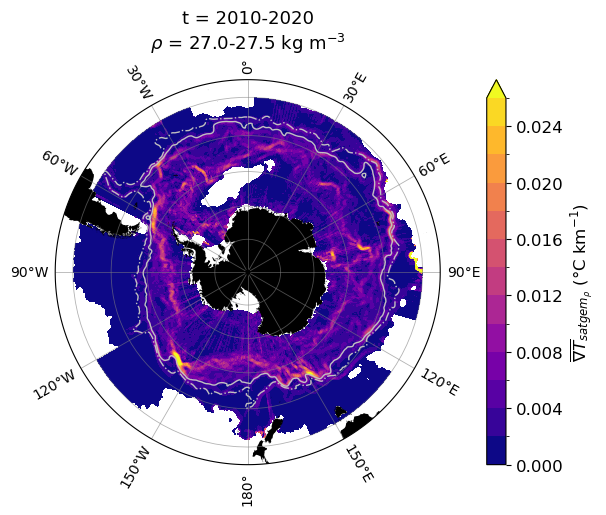

In [31]:
fig, ax = func.plot_circmupolar(mean_t_grad, cmap = 'plasma', levels = np.arange(0, 0.028, 0.002), clabel = r'$\overline{\nabla T}_{satgem_\rho}$ (°C km$^{-1}$)')

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='silver', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='silver', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title('t = 2010-2020' + '\n' + r'$\rho$ = 27.0-27.5 kg m$^{-3}$',  fontsize = 13)

In [ ]:
# name = f'circumpolar_satgem_Tgrad.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches = 0.2)

#### Averaged in the PFZ

In [32]:
PF = -0.3
nSAF = 0

t_grad_PFZ = func.mask_PFZ(mean_t_grad, circumpolar_mdt.adt, limits = [PF, nSAF], pad = 0.1)

In [33]:
window = int(3/0.25)

In [34]:
mean_t_grad_PFZ = t_grad_PFZ.mean('latitude')

In [43]:
def mark_topography(ax, label_y = 0.0165):
    ax.axvspan(xmin = 15, xmax = 40, color = 'grey', alpha = 0.1)
    ax.axvspan(xmin = 62, xmax = 80, color = 'grey', alpha = 0.1)
    ax.axvspan(xmin = 110, xmax = 140, color = 'grey', alpha = 0.1)
    ax.axvspan(xmin = 145, xmax = 160, color = 'grey', alpha = 0.25)
    ax.axvspan(xmin = 165, xmax = 178, color = 'grey', alpha = 0.1)
    ax.axvspan(xmin = 210, xmax = 230, color = 'grey', alpha = 0.1)
    ax.axvspan(xmin = 285, xmax = 300, color = 'grey', alpha = 0.25)
    ax.axvspan(xmin = 305, xmax = 325, color = 'grey', alpha = 0.1)
    
    ax.text(16, label_y, 'SWIR', fontsize = 9)
    ax.text(66, label_y, 'KP', fontsize = 9)
    ax.text(116, label_y, 'SEIR', fontsize = 9)
    ax.text(146.5, label_y, 'MR', fontsize = 9)
    ax.text(166, label_y, 'CP', fontsize = 9)
    ax.text(212, label_y, 'PAR', fontsize = 9)
    ax.text(287, label_y, 'DP', fontsize = 9)
    ax.text(306, label_y, 'BMC', fontsize = 9)

Text(0.5, 0, 'Longitude (°E)')

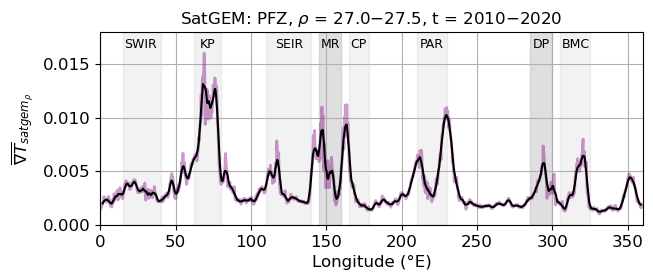

In [37]:
fig, ax = plt.subplots(figsize = (7,2.5))
mean_t_grad_PFZ.plot(c = 'purple', alpha = 0.4, linewidth = 2)
mean_t_grad_PFZ.rolling(longitude = window, center = True).mean().plot(c='k')

mark_topography(ax)

ax.set_ylabel(r'$\overline{\nabla T}_{satgem_\rho}$')
ax.set_ylim(0, 0.018)
ax.grid()
ax.set_xlim(0, 360)

plt.title(r'SatGEM: PFZ, $\rho$ = 27.0$-$27.5, t = 2010$-$2020', fontsize = 12)
plt.xlabel('Longitude (°E)')

### Eddy kinetic energy (EKE)

Calculated from satellite geostrophic velocities (CMEMS), using annual mean reference velocities.

In [38]:
mean_eke = xr.open_dataset('data/circumpolar_eke_mean.nc').__xarray_dataarray_variable__
# mean_eke = xr.open_dataset('data/circumpolar_eke_rolling_mean.nc').__xarray_dataarray_variable__

Text(0.5, 1.0, 't = 2010$-$2020 \n annual mean')

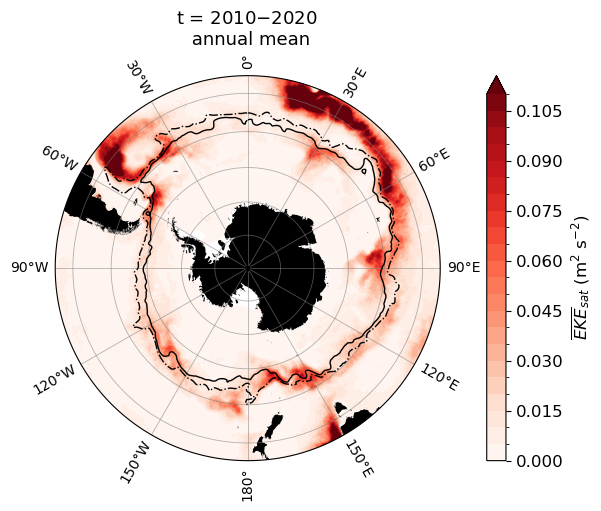

In [39]:
levels = np.arange(0, 0.115, 0.005)
# levels = np.arange(0, 0.05, 0.002)

fig, ax = func.plot_circmupolar(mean_eke, clabel = r'$\overline{EKE}_{sat}$ (m$^{2}$ s$^{-2}$)', cmap = 'Reds', levels = levels)

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title(f't = 2010$-$2020 \n annual mean', fontsize = 13)
# ax.set_title(f't = 2010$-$2020 \n rolling mean = 30 days', fontsize = 13)

In [40]:
# name = f'circumpolar_sat_EKE.png'
# name = f'circumpolar_sat_rolling_EKE.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches = 0.2)

#### Averaged in the PFZ

In [ ]:
eke_PFZ = func.mask_PFZ(mean_eke, circumpolar_mdt.adt, limits = [-0.3, 0], pad = 0.1)
mean_eke_PFZ = eke_PFZ.mean('latitude')

Text(0.5, 0, 'Longitude (°E)')

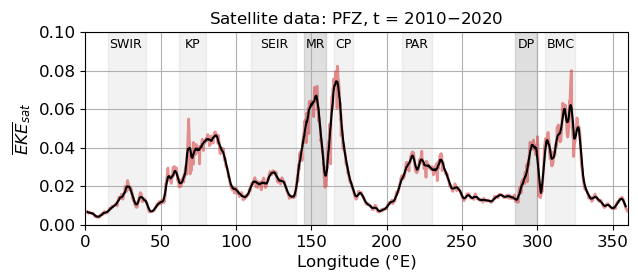

In [52]:
fig, ax = plt.subplots(figsize = (7,2.5))
mean_eke_PFZ.plot(c = 'tab:red', alpha = 0.5, linewidth = 2)
mean_eke_PFZ.rolling(longitude = window, center = True).mean().plot(c='k')

mark_topography(ax, label_y = 0.092)

ax.set_ylabel(r'$\overline{EKE}_{sat}$')
ax.set_ylim(0, 0.1)
ax.grid()
ax.set_xlim(0, 360)

plt.title(r'Satellite data: PFZ, t = 2010$-$2020', fontsize = 12)
plt.xlabel('Longitude (°E)')

### Sea surface height (SSH) standard deviation

In [53]:
circumpolar_ssh_std = xr.open_dataset('data/circumpolar_ssh_std_2010-2020.nc').adt

Text(0.5, 1.0, 't = 2010$-$2020')

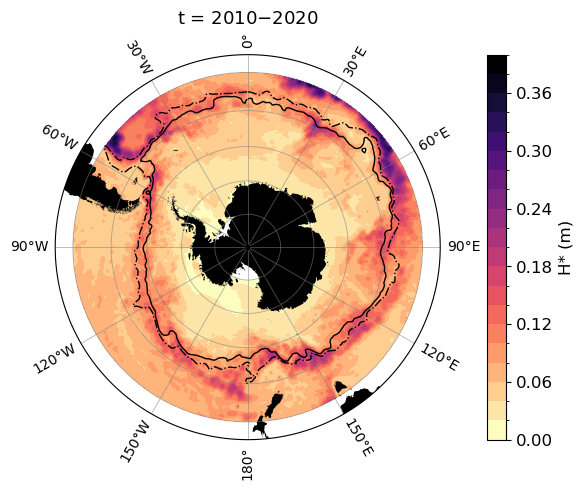

In [54]:
levels = np.arange(0, 0.42, 0.02)

fig, ax = func.plot_circmupolar(circumpolar_ssh_std, clabel = 'H* (m)', cmap = 'magma_r', levels = levels)

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title(f't = 2010$-$2020', fontsize = 13)
# ax.set_title(f't = 2010$-$2020 \n rolling mean = 30 days', fontsize = 13)

In [ ]:
# name = f'circumpolar_ssh_std.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches = 0.2)

In [55]:
ssh_std_PFZ = func.mask_PFZ(circumpolar_ssh_std, circumpolar_mdt.adt, limits = [-0.3, 0], pad = 0.1)
mean_ssh_std_PFZ = ssh_std_PFZ.mean('latitude')

Text(0.5, 0, 'Longitude (°E)')

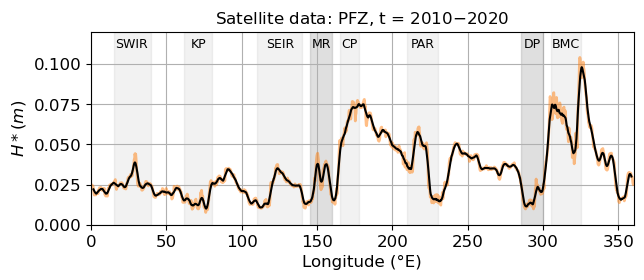

In [59]:
fig, ax = plt.subplots(figsize = (7,2.5))
mean_ssh_std_PFZ.plot(c = 'tab:orange', alpha = 0.5, linewidth = 2)
mean_ssh_std_PFZ.rolling(longitude = window, center = True).mean().plot(c='k')

mark_topography(ax, label_y = 0.11)

ax.set_ylabel(r'$H* (m)$')
ax.set_ylim(0, 0.12)
ax.grid()
ax.set_xlim(0, 360)

plt.title(r'Satellite data: PFZ, t = 2010$-$2020', fontsize = 12)
plt.xlabel('Longitude (°E)')

### Plot circumpolar Diapycnal Spiciness Curvature (DSC) from in-situ observations (Jakes et al. 2025) 

#### Mean DSC from density 27.0 to 27.5 kg/m^3

In [67]:
# dsc = xr.open_dataset('/g/data/jk72/mj0995/data/dsc_circumpolar.nc').__xarray_dataarray_variable__
# mean_dsc = abs(dsc).sel(density = slice(27.0, 27.5)).mean(dim = 'density', skipna = True)

In [68]:
mean_dsc_dens = xr.open_dataset('/g/data/jk72/mj0995/data/mean_dsc_circumpolar_27.0to27.5.nc').__xarray_dataarray_variable__

In [69]:
dsc_grid_dens, n_obs = func.grid_data(mean_dsc_dens, grid_size = 1, min_obs = 5)

Text(0.5, 1.0, 't = 2010$-$2020 \n$\\rho$ = 27.0-27.5 kg m$^{-3}$')

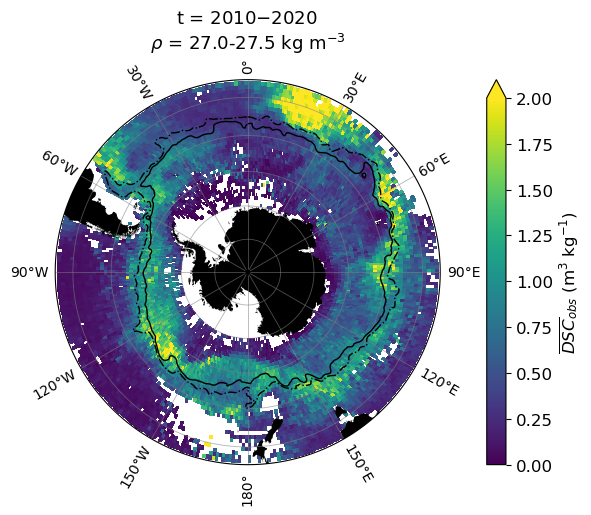

In [70]:
fig, ax = func.plot_circmupolar(dsc_grid_dens, cmap = 'viridis', contourf = False, vmin = 0, vmax = 2, clabel = '$\overline{DSC}_{obs}$ (m$^{3}$ kg$^{-1}$)')

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title('t = 2010$-$2020 \n' + r'$\rho$ = 27.0-27.5 kg m$^{-3}$', fontsize = 13)

In [ ]:
# name = f'circumpolar_DSC_27-27.5.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches = 0.2)

#### Mean DSC from MLD to 1000 dbar

In [71]:
mean_dsc = xr.open_dataset('/g/data/jk72/mj0995/data/mean_dsc_circumpolar.nc').__xarray_dataarray_variable__

In [72]:
dsc_grid, n_obs = func.grid_data(mean_dsc, grid_size = 1, min_obs = 5)

Text(0.5, 1.0, 't = 2010$-$2020 \nMLD-1000 dbar')

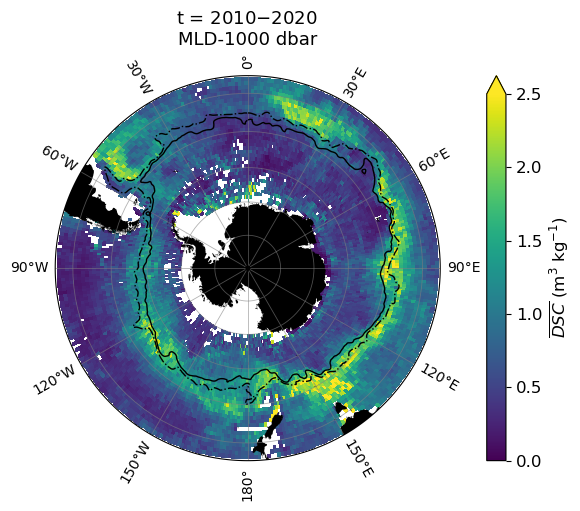

In [74]:
fig, ax = func.plot_circmupolar(dsc_grid, cmap = 'viridis', contourf = False, clabel = '$\overline{DSC}$ (m$^{3}$ kg$^{-1}$)', vmin = 0, vmax = 2.5)

circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title('t = 2010$-$2020 \n' + r'MLD-1000 dbar', fontsize = 13)

In [ ]:
# name = f'circumpolar_DSC_mld_to_1000.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches = 0.2)

#### Averaged in the PFZ

In [75]:
def lon_0_to_360(data):
    neg_lon = np.where(data['longitude'].data < 0)[0]
    data.longitude.data[neg_lon] += 360
    return data.sortby('longitude')

In [76]:
dsc_grid_dens_copy = dsc_grid_dens.copy()

In [77]:
dsc_grid_0_360 = lon_0_to_360(dsc_grid_dens_copy.sel(longitude = slice(-180, 180)))

In [78]:
dsc_PFZ = func.mask_PFZ(dsc_grid_0_360, circumpolar_mdt.adt, limits = [-0.3, 0], pad = 0.1)
mean_dsc_PFZ = dsc_PFZ.mean(dim = 'latitude')
# mean_dsc_PFZ = mean_dsc_PFZ.drop_duplicates('longitude', keep='first')

Text(0.5, 0, 'Longitude (°E)')

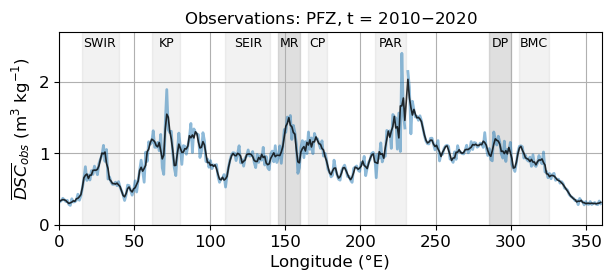

In [89]:
fig, ax = plt.subplots(figsize = (7,2.5))
mean_dsc_PFZ.plot(c = 'tab:blue', alpha = 0.5, linewidth = 2)
mean_dsc_PFZ.rolling(longitude = 3, center = True, min_periods = 2).mean().plot(c = 'k', alpha = 0.8, linewidth = 1.2)

mark_topography(ax, label_y = 2.5)

ax.set_ylabel(r'$\overline{DSC}_{obs}$ (m$^{3}$ kg$^{-1}$)')
ax.set_ylim(0, 2.7)
ax.grid()
ax.set_xlim(0, 360)

plt.title(r'Observations: PFZ, t = 2010$-$2020', fontsize = 12)
plt.xlabel('Longitude (°E)')

### All datasets averaged in the PFZ

Text(0.5, 1.0, 'PFZ: t = 2010$-$2020')

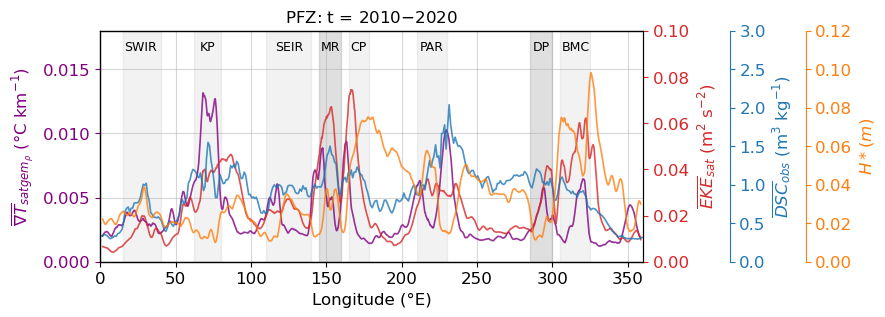

In [90]:
fig, ax = plt.subplots(figsize = (7,3))
mean_t_grad_PFZ.rolling(longitude = window, center = True).mean().plot(c = 'purple', alpha = 0.8, linewidth = 1.2)

mark_topography(ax)

ax.set_ylabel(r'$\overline{\nabla T}_{satgem_\rho}$ (°C km$^{-1}$)', c = 'purple')
ax.set_xlabel('Longitude (°E)')
ax.set_ylim(0, 0.018)
ax.grid(alpha = 0.5)
ax.set_xlim(0, 360)
ax.tick_params(axis='y', colors='purple')

ax2 = ax.twinx()
mean_eke_PFZ.rolling(longitude = window, center = True).mean().plot(ax = ax2, c = 'tab:red', alpha = 0.8, linewidth = 1.2)
ax2.set_ylabel(r'$\overline{EKE}_{sat}$ (m$^{2}$ s$^{-2}$)', c = 'tab:red')
ax2.set_ylim(0, 0.1)
ax2.tick_params(axis='y', colors='tab:red')

ax3 = ax.twinx()
mean_dsc_PFZ.rolling(longitude = 3, center = True, min_periods = 2).mean().plot(ax = ax3, c = 'tab:blue', alpha = 0.8, linewidth = 1.2)
ax3.set_ylabel(r'$\overline{DSC}_{obs}$ (m$^{3}$ kg$^{-1}$)', c = 'tab:blue')
ax3.set_ylim(0, 3)
ax3.spines['right'].set_position(("axes", 1.16))
ax3.spines['right'].set_color('tab:blue')
ax3.tick_params(axis='y', colors='tab:blue')

ax4 = ax.twinx()
mean_ssh_std_PFZ.rolling(longitude = window, center = True).mean().plot(ax = ax4, c = 'tab:orange', alpha = 0.8, linewidth = 1.2)
ax4.set_ylabel(r'$H* (m)$', c = 'tab:orange'
              )
ax4.set_ylim(0, 0.12)
ax4.spines['right'].set_position(("axes", 1.3))
ax4.spines['right'].set_color('tab:orange')
ax4.tick_params(axis='y', colors='tab:orange')

plt.title(r'PFZ: t = 2010$-$2020', fontsize = 12)

In [ ]:
# name = f'avg_PFZ_vars_nostd.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches = 0.2)

Text(0.5, 1.0, 'PFZ: t = 2010$-$2020')

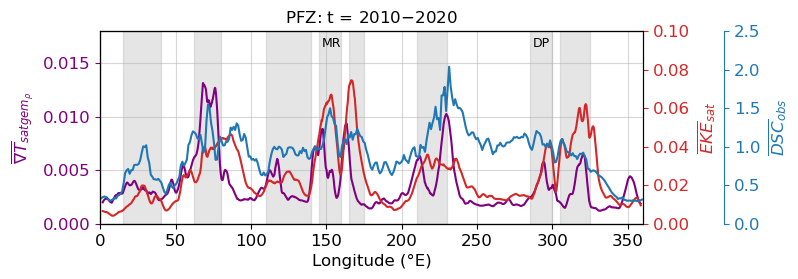

In [91]:
fig, ax = plt.subplots(figsize = (7,2.5))
mean_t_grad_PFZ.rolling(longitude = window, center = True).mean().plot(c = 'purple')

ax.axvspan(xmin = 62, xmax = 80, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 145, xmax = 160, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 210, xmax = 230, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 285, xmax = 300, color = 'grey', alpha = 0.2)

ax.axvspan(xmin = 15, xmax = 40, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 110, xmax = 140, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 165, xmax = 175, color = 'grey', alpha = 0.2)
ax.axvspan(xmin = 305, xmax = 325, color = 'grey', alpha = 0.2)

ax.text(147, 0.0165, 'MR', fontsize = 9)
ax.text(287, 0.0165, 'DP', fontsize = 9)

ax.set_ylabel(r'$\overline{\nabla T}_{satgem_\rho}$', c = 'purple')
ax.set_xlabel('Longitude (°E)')
ax.set_ylim(0, 0.018)
ax.grid(alpha = 0.5)
ax.set_xlim(0, 360)
ax.tick_params(axis='y', colors='purple')

ax2 = ax.twinx()
mean_eke_PFZ.rolling(longitude = window, center = True).mean().plot(ax = ax2, c = 'tab:red')
ax2.set_ylabel(r'$\overline{EKE}_{sat}$', c = 'tab:red')
ax2.set_ylim(0, 0.1)
ax2.tick_params(axis='y', colors='tab:red')

ax3 = ax.twinx()
mean_dsc_PFZ.rolling(longitude = 3, center = True, min_periods = 2).mean().plot(ax = ax3, c = 'tab:blue')
ax3.set_ylabel(r'$\overline{DSC}_{obs}$', c = 'tab:blue', fontweight = 'bold')
ax3.set_ylim(0, 2.5)
ax3.spines['right'].set_position(("axes", 1.15))
ax3.spines['right'].set_color('tab:blue')
ax3.tick_params(axis='y', colors='tab:blue')

plt.title(r'PFZ: t = 2010$-$2020', fontsize = 12)

In [ ]:
# name = f'avg_PFZ_vars_dsc_27_to_27.5.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches = 0.2)